# Sensitivities

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    sweep_4d,
    evaluate,
    file_path,
    analyse_sweep
    )

### Initialize the System / Problem

In [3]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [4]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

### Load the Optimals

In [5]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")
#optimals = np.array([3.9706556509695288, 3.0250041828254846, 0.074609375, 0.7299271700356719])
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.9836391966759
Optimal delta_v: 3.0260560941828256
Optimal delta_v_angle: 0.10454120498614959
Optimal tof: 0.7745498614958449


In [6]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: 1.3895107773883447e-06
Objective value: 3.885171292500793
Constraint Value in km: 0.5341279428280796
Objective Value in km/s: 3.980472085652485


In [7]:
grid_spacings = [0.00088816,
                 0.00115132,
                 0.00031086,
                 0.00138158]

In [ ]:
cache_path = Path(f"{file_path}/sweep_4d_results.npy")

if cache_path.exists():
    print(f"Loading cached sweep...")
    results = pd.DataFrame(
        np.load(cache_path),
        columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
    )
else:
    print(f"Computing 4D sweep...")
    results = sweep_4d(
        em, 
        optimal_x0=optimals,
        deltas=grid_spacings,
        n_samples=400000,
        tol=2.6e-6,
        leo_alt_m=leo_alt_m,
        lmo_alt_m=lmo_alt_m,
        seed=42
    )
    np.save(cache_path, results)

Loading cached sweep...


Optimal solution from sweep:
  theta:         3.984350
  delta_v:       3.02597910
  delta_v_angle: 0.104560
  tof:           0.775214
  total_delta_v: 3.86271066
  distance_to_lmo: -3.86e-08


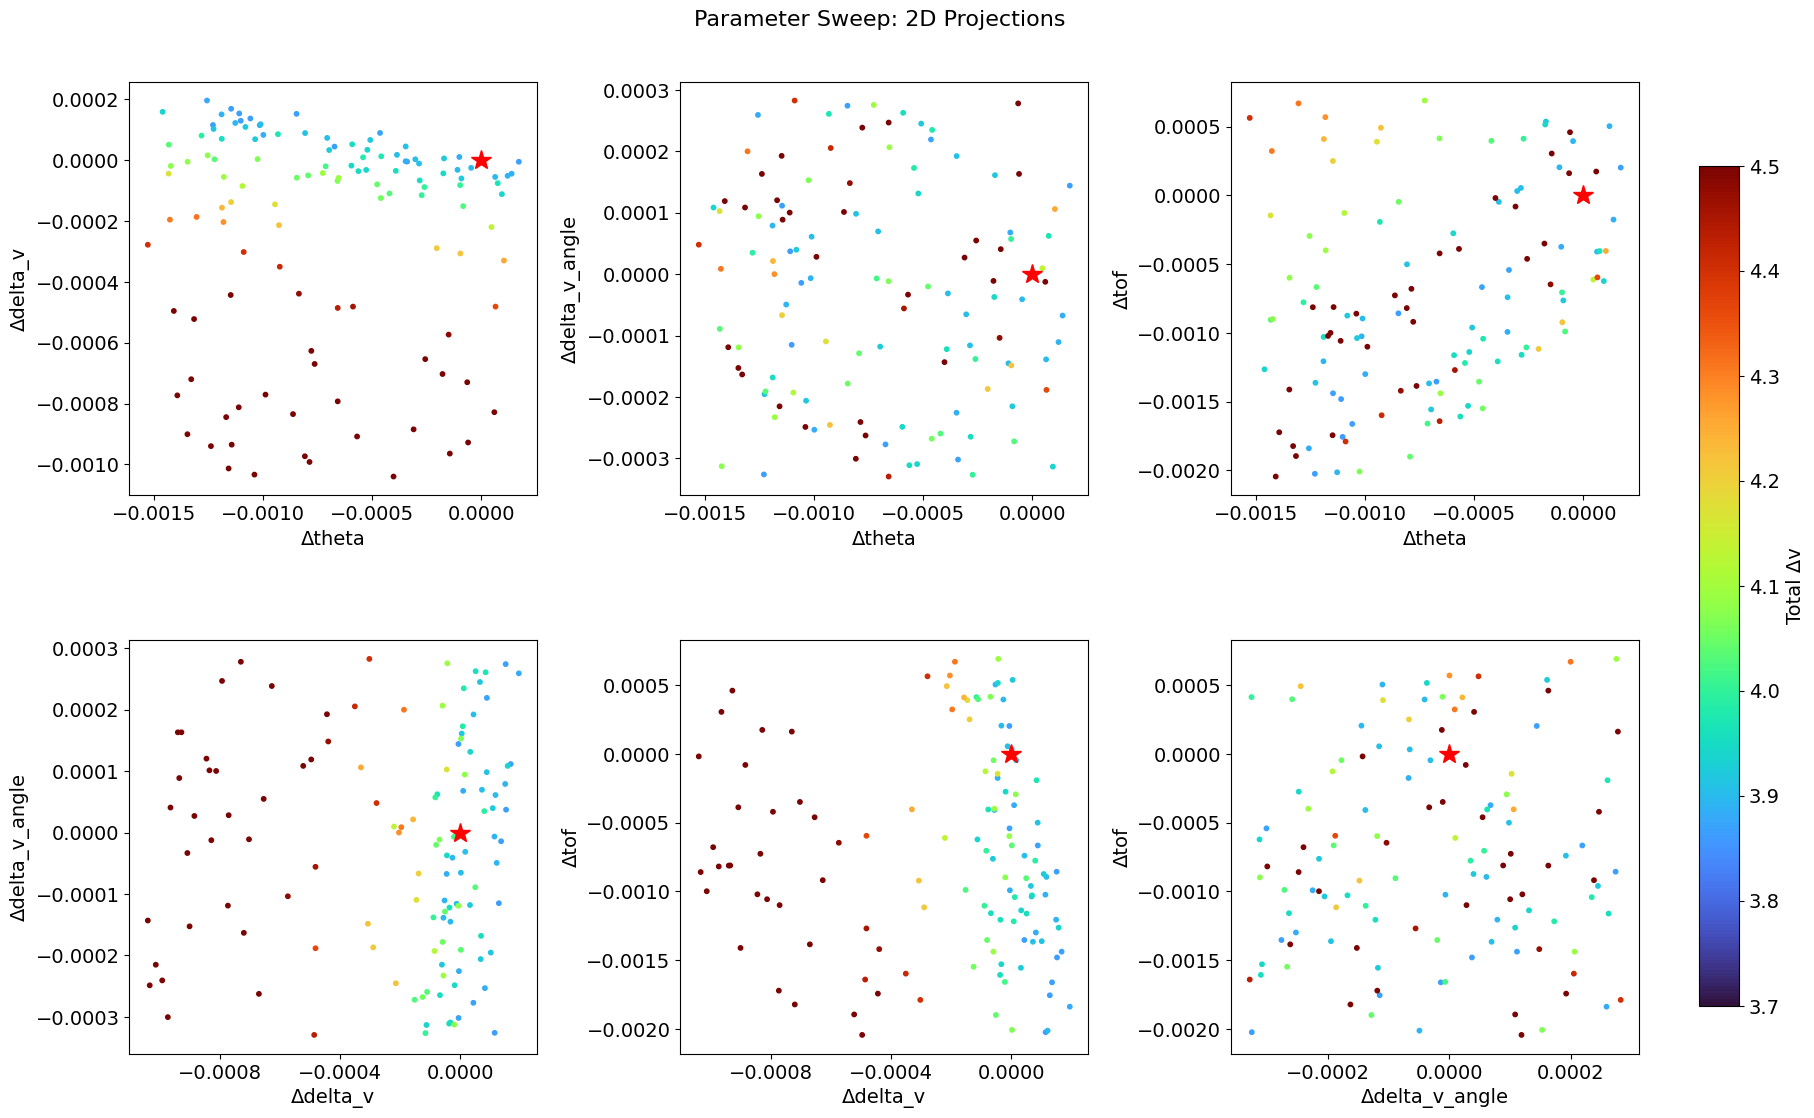

In [12]:
optimal, fig = analyse_sweep(results)